In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')

# ── Dataset parameters ────────────────────────────────────────────────────────
N = 500

firs         = ['LECM', 'LFFF', 'EDGG', 'EBBU', 'EGTT']   # Spanish, French, German, Belgian, UK
event_types  = ['AIRPROX', 'Weather Deviation', 'Communication Loss',
                'TCAS RA', 'Runway Incursion', 'Separation Event']
phases       = ['En-Route', 'Climb', 'Descent', 'Approach', 'Departure']
severities   = ['Low', 'Medium', 'High', 'Critical']
shift        = ['Morning', 'Afternoon', 'Night']
aircraft_cat = ['Heavy', 'Medium', 'Light', 'Super']

# ── Biased sampling (makes plots more interesting) ────────────────────────────
fir_probs    = [0.25, 0.22, 0.20, 0.15, 0.18]
event_probs  = [0.10, 0.28, 0.15, 0.20, 0.08, 0.19]
phase_probs  = [0.40, 0.15, 0.20, 0.18, 0.07]
sev_probs    = [0.35, 0.38, 0.18, 0.09]

df = pd.DataFrame({
    'event_id'     : [f'EVT-{i:04d}' for i in range(N)],
    'fir'          : np.random.choice(firs, N, p=fir_probs),
    'event_type'   : np.random.choice(event_types, N, p=event_probs),
    'phase'        : np.random.choice(phases, N, p=phase_probs),
    'severity'     : np.random.choice(severities, N, p=sev_probs),
    'shift'        : np.random.choice(shift, N),
    'aircraft_cat' : np.random.choice(aircraft_cat, N, p=[0.35,0.45,0.12,0.08]),
    'flight_level' : np.random.normal(280, 60, N).clip(50, 450).astype(int),
    'resolution_min': np.random.exponential(scale=18, size=N).clip(1, 120).round(1),
    'controllers_on_duty': np.random.randint(2, 9, N),
    'traffic_count': np.random.poisson(lam=35, size=N),
    'year'         : np.random.choice([2020,2021,2022,2023,2024], N,
                                       p=[0.10,0.12,0.20,0.30,0.28]),
})

# Add a continuous severity score (correlated with severity label)
sev_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
df['severity_score'] = df['severity'].map(sev_map) + np.random.normal(0, 0.4, N)
df['severity_score'] = df['severity_score'].clip(0.5, 5).round(2)

# Make critical events take longer to resolve
df.loc[df['severity']=='Critical', 'resolution_min'] *= 2.5
df.loc[df['severity']=='High',     'resolution_min'] *= 1.5
df['resolution_min'] = df['resolution_min'].clip(1, 180).round(1)

# Ordered categorical for severity (useful for many plots)
sev_order = ['Low', 'Medium', 'High', 'Critical']
df['severity'] = pd.Categorical(df['severity'], categories=sev_order, ordered=True)

print(df.shape)
df.head()

(500, 13)


,event_id,fir,event_type,phase,severity,shift,aircraft_cat,flight_level,resolution_min,controllers_on_duty,traffic_count,year,severity_score
0,EVT-0000,LFFF,TCAS RA,En-Route,Medium,Night,Medium,286,21.6,4,35,2024,2.01
1,EVT-0001,EGTT,TCAS RA,Climb,Medium,Night,Super,315,32.8,8,27,2022,1.62
2,EVT-0002,EBBU,Weather Deviation,Approach,Low,Night,Medium,351,29.2,8,43,2023,0.97
3,EVT-0003,EDGG,Separation Event,Descent,Low,Afternoon,Medium,244,58.4,8,66,2020,0.86
4,EVT-0004,LECM,TCAS RA,Approach,Medium,Afternoon,Medium,304,13.8,8,37,2023,2.07


<Axes: xlabel='year', ylabel='count'>

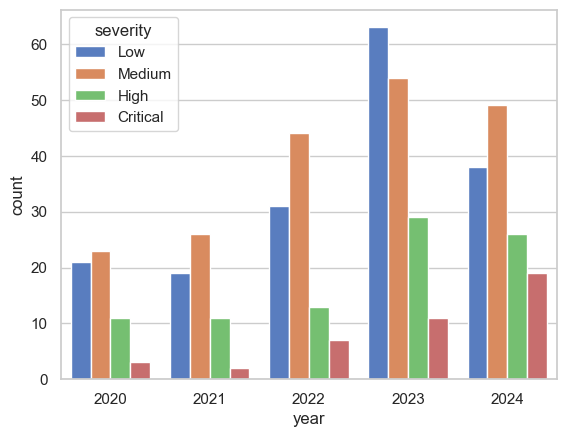

In [4]:
sns.countplot(data=df, x="year", hue="severity")

<Axes: xlabel='flight_level', ylabel='Count'>

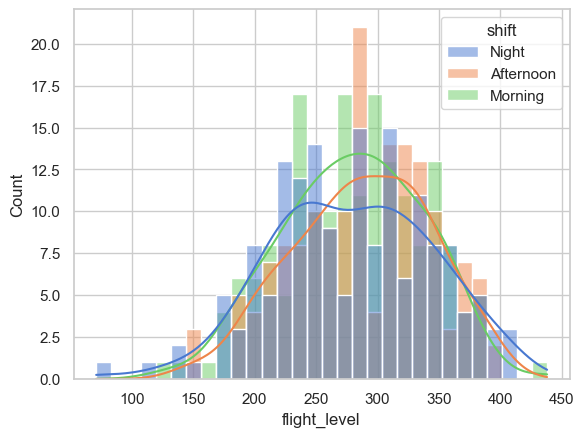

In [5]:
sns.histplot(data=df, x="flight_level", hue="shift", palette="muted", multiple="layer", bins=30, kde=True)

<Axes: xlabel='flight_level', ylabel='severity_score'>

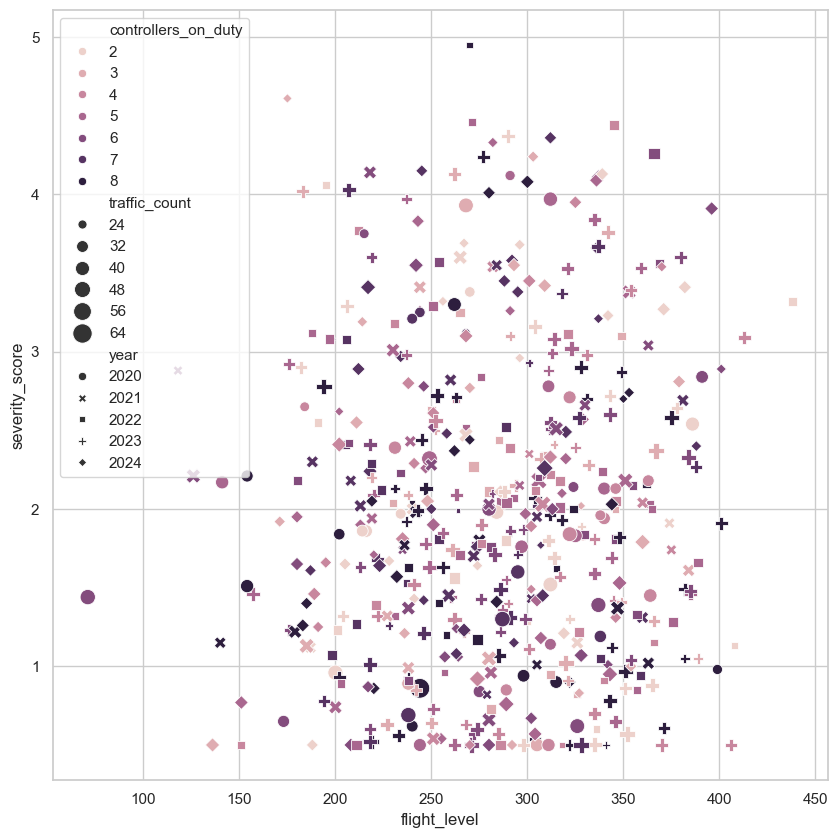

In [6]:
plt.figure(figsize=(10, 10))
sns.scatterplot(data=df, x="flight_level", y="severity_score", hue="controllers_on_duty", style="year", size="traffic_count", sizes=(20, 200))

<Axes: >

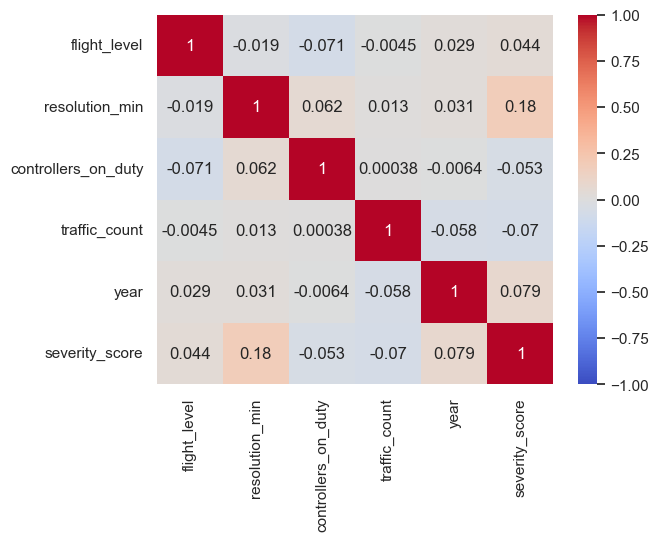

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, cmap='coolwarm')
# We must ensure that the input data doesn't contain multicollinearity, meaning predictors are not independent, as it may cause issues with mathematical calculations. 
# By identifying and eliminating redundant or correlated features, 
# we can ensure that each feature in our dataset offers unique and valuable information that improves the predictive model's performance.

<Axes: xlabel='year', ylabel='flight_level'>

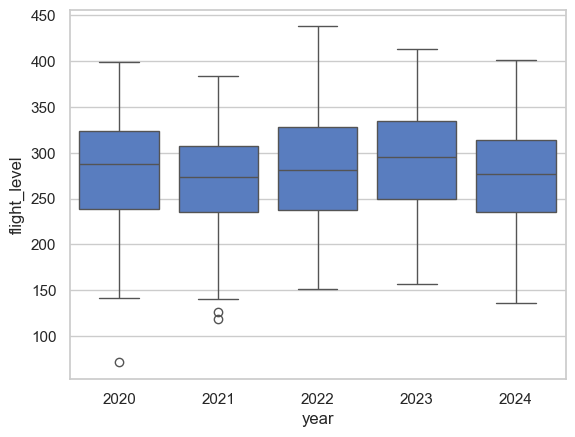

In [8]:
sns.boxplot(data=df, x="year", y="flight_level")

In [9]:
display(df.head(), df.shape)

,event_id,fir,event_type,phase,severity,shift,aircraft_cat,flight_level,resolution_min,controllers_on_duty,traffic_count,year,severity_score
0,EVT-0000,LFFF,TCAS RA,En-Route,Medium,Night,Medium,286,21.6,4,35,2024,2.01
1,EVT-0001,EGTT,TCAS RA,Climb,Medium,Night,Super,315,32.8,8,27,2022,1.62
2,EVT-0002,EBBU,Weather Deviation,Approach,Low,Night,Medium,351,29.2,8,43,2023,0.97
3,EVT-0003,EDGG,Separation Event,Descent,Low,Afternoon,Medium,244,58.4,8,66,2020,0.86
4,EVT-0004,LECM,TCAS RA,Approach,Medium,Afternoon,Medium,304,13.8,8,37,2023,2.07


(500, 13)

year,2020,2021,2022,2023,2024
controllers_on_duty,,,,,
2,2.008750,2.041667,1.948889,1.911765,2.526667
3,1.787500,1.585000,2.056667,2.004091,2.291765
4,1.872727,2.040000,2.006111,1.613684,2.146316
5,2.272000,2.107778,2.043333,2.147037,2.077826
6,1.741111,2.320000,2.285000,1.760909,1.857222
7,2.051429,2.018333,1.840000,1.902353,2.504615
8,1.462222,1.415000,2.018889,1.727273,2.130000


<Axes: xlabel='controllers_on_duty'>

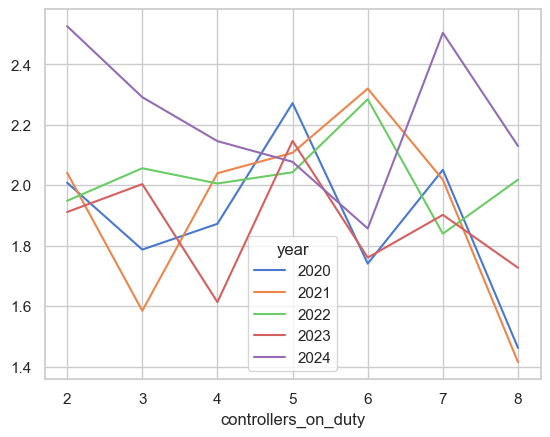

In [10]:
# there cannot be duplciates in the pivot table, so we drop duplicates first
mean_df = df.groupby(["controllers_on_duty", "year"]).agg({"severity_score": "mean"}).reset_index()
pivot_df = mean_df.pivot(index="controllers_on_duty", columns="year", values="severity_score")
display(pivot_df)
pivot_df.plot()

<Axes: xlabel='flight_level'>

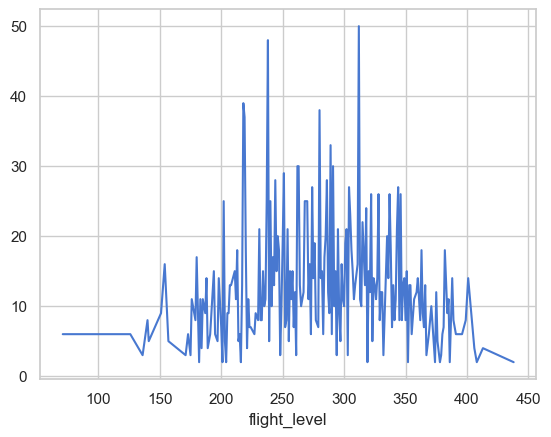

In [11]:
fl_wise_data = df.groupby("flight_level")["controllers_on_duty"].sum()
fl_wise_data.plot()

0.11357240294235438


d:\Pablo_Data\Documentos\VSCode\revolut\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.16711269, 2.22735093])

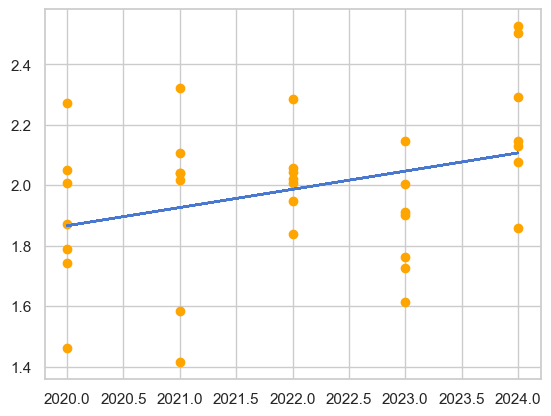

In [12]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(mean_df[["year"]], mean_df["severity_score"])
severity_predict = model.predict(mean_df[["year"]])
plt.plot(mean_df["year"], severity_predict)
plt.scatter(mean_df["year"], mean_df["severity_score"], color="orange")
print(model.score(mean_df[["year"]], mean_df["severity_score"]))
model.predict([[2025], [2026]])

In [13]:
df.isnull().sum()

event_id               0
fir                    0
event_type             0
phase                  0
severity               0
shift                  0
aircraft_cat           0
flight_level           0
resolution_min         0
controllers_on_duty    0
traffic_count          0
year                   0
severity_score         0
dtype: int64

<Axes: >

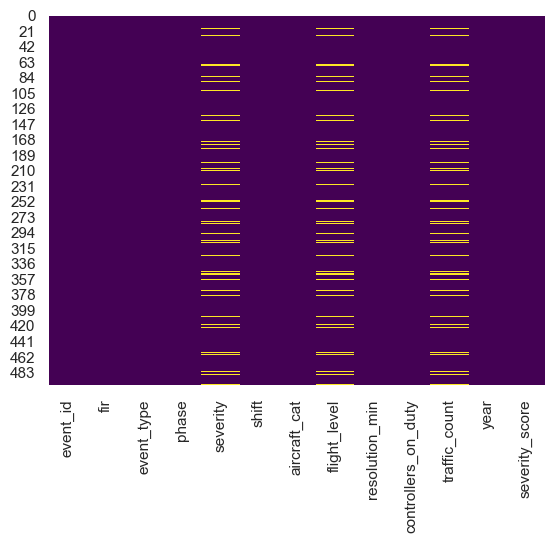

In [14]:
# generate a random df with missing values
df_missing = df.copy()
missing_indices = np.random.choice(df_missing.index, size=int(0.1 * len(df_missing)), replace=False)
cols_with_missing = np.random.choice(df_missing.columns, size=3, replace=False)
for col in cols_with_missing:
    df_missing.loc[missing_indices, col] = np.nan

sns.heatmap(df_missing.isnull(), cbar=False, cmap='viridis')

In [15]:
df_missing["controllers_on_duty"].fillna(df_missing["controllers_on_duty"].median())
df_missing["controllers_on_duty"].bfill() # backward fill to fill NaN values with the next valid observation


0      4
1      8
2      8
3      8
4      8
      ..
495    5
496    7
497    7
498    4
499    7
Name: controllers_on_duty, Length: 500, dtype: int32

In [16]:
# we can use pd.factorize as label encoding for categorical variables.

df["aircraft_cat_encoded"] = pd.factorize(df["aircraft_cat"])[0]
df[["aircraft_cat", "aircraft_cat_encoded"]].drop_duplicates()

,aircraft_cat,aircraft_cat_encoded
0,Medium,0
1,Super,1
6,Heavy,2
8,Light,3


In [17]:
# use now pd.get_dummies to one-hot encode categorical variables with no ordinal realationship
pd.get_dummies(df["shift"], prefix="shift", drop_first=True)

,shift_Morning,shift_Night
0,False,True
1,False,True
2,False,True
3,False,False
4,False,False
...,...,...
495,False,True
496,True,False
497,True,False
498,False,False


In [30]:
df.describe()

,flight_level,resolution_min,controllers_on_duty,traffic_count,year,severity_score,aircraft_cat_encoded
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.0000
mean,282.220000,20.763000,5.162000,35.146000,2022.494000,2.00868,1.1040
std,59.280384,22.407621,1.912871,5.972942,1.307434,0.99374,1.1116
min,71.000000,1.000000,2.000000,18.000000,2020.000000,0.50000,0.0000
25%,239.750000,5.600000,4.000000,31.000000,2022.000000,1.23000,0.0000
50%,285.000000,13.300000,5.000000,35.000000,2023.000000,1.94000,1.0000
75%,326.250000,29.200000,7.000000,39.000000,2024.000000,2.63250,2.0000
max,438.000000,180.000000,8.000000,66.000000,2024.000000,4.95000,3.0000


In [34]:
# Define the bin edges
age_bins = [0, 70, 150, 350, 450]

# Define the bin labels
age_labels = ['Very Low', 'Low', 'Normal', 'High']

# Create the age group feature
df["flight_level_cat"] = pd.cut(df['flight_level'], bins=age_bins, labels=age_labels)
df

,event_id,fir,event_type,phase,severity,shift,aircraft_cat,flight_level,resolution_min,controllers_on_duty,traffic_count,year,severity_score,aircraft_cat_encoded,flight_level_cat
0,EVT-0000,LFFF,TCAS RA,En-Route,Medium,Night,Medium,286,21.6,4,35,2024,2.01,0,Normal
1,EVT-0001,EGTT,TCAS RA,Climb,Medium,Night,Super,315,32.8,8,27,2022,1.62,1,Normal
2,EVT-0002,EBBU,Weather Deviation,Approach,Low,Night,Medium,351,29.2,8,43,2023,0.97,0,High
3,EVT-0003,EDGG,Separation Event,Descent,Low,Afternoon,Medium,244,58.4,8,66,2020,0.86,0,Normal
4,EVT-0004,LECM,TCAS RA,Approach,Medium,Afternoon,Medium,304,13.8,8,37,2023,2.07,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,EVT-0495,LFFF,AIRPROX,Descent,Medium,Night,Medium,389,16.0,5,39,2022,1.66,0,High
496,EVT-0496,EDGG,Separation Event,Descent,Critical,Morning,Medium,337,22.8,7,40,2023,3.67,0,Normal
497,EVT-0497,LECM,Weather Deviation,Climb,Low,Morning,Medium,308,65.6,7,40,2024,1.45,0,Normal
498,EVT-0498,EGTT,Separation Event,En-Route,Low,Afternoon,Medium,311,14.1,4,37,2020,0.50,0,Normal


In [25]:
from sklearn.preprocessing import StandardScaler # transform into z-score (standarized)
from sklearn.preprocessing import MinMaxScaler # normalized
from sklearn.preprocessing import RobustScaler # used when we have outliers since it uses IQR
std_scaler = StandardScaler() 
min_max_scaler = MinMaxScaler()
robust_scaler = RobustScaler()
print(std_scaler.fit(df[["year"]]).transform(df[["year"]]))
print(min_max_scaler.fit_transform(df[["year"]]))
print(robust_scaler.fit_transform(df[["year"]]))

[[ 1.1530285 ]
 [-0.37821785]
 [ 0.38740532]
 [-1.90946419]
 [ 0.38740532]
 [ 1.1530285 ]
 [-0.37821785]
 [-0.37821785]
 [ 0.38740532]
 [ 1.1530285 ]
 [-0.37821785]
 [-0.37821785]
 [ 1.1530285 ]
 [ 0.38740532]
 [-1.14384102]
 [-1.90946419]
 [ 0.38740532]
 [-0.37821785]
 [-0.37821785]
 [ 1.1530285 ]
 [-1.90946419]
 [ 0.38740532]
 [-0.37821785]
 [ 1.1530285 ]
 [ 1.1530285 ]
 [-1.90946419]
 [ 0.38740532]
 [-1.14384102]
 [ 1.1530285 ]
 [ 1.1530285 ]
 [-0.37821785]
 [ 0.38740532]
 [-0.37821785]
 [ 0.38740532]
 [-0.37821785]
 [-0.37821785]
 [ 0.38740532]
 [-1.90946419]
 [ 1.1530285 ]
 [-1.90946419]
 [ 0.38740532]
 [-1.14384102]
 [-0.37821785]
 [ 0.38740532]
 [ 1.1530285 ]
 [ 1.1530285 ]
 [-0.37821785]
 [-1.14384102]
 [ 1.1530285 ]
 [ 0.38740532]
 [-1.14384102]
 [ 1.1530285 ]
 [ 1.1530285 ]
 [ 1.1530285 ]
 [ 1.1530285 ]
 [ 1.1530285 ]
 [-1.90946419]
 [-1.14384102]
 [ 0.38740532]
 [ 0.38740532]
 [ 0.38740532]
 [-0.37821785]
 [ 0.38740532]
 [ 0.38740532]
 [-1.90946419]
 [-0.37821785]
 [ 0.38740

In [26]:
df.head()

,event_id,fir,event_type,phase,severity,shift,aircraft_cat,flight_level,resolution_min,controllers_on_duty,traffic_count,year,severity_score,aircraft_cat_encoded
0,EVT-0000,LFFF,TCAS RA,En-Route,Medium,Night,Medium,286,21.6,4,35,2024,2.01,0
1,EVT-0001,EGTT,TCAS RA,Climb,Medium,Night,Super,315,32.8,8,27,2022,1.62,1
2,EVT-0002,EBBU,Weather Deviation,Approach,Low,Night,Medium,351,29.2,8,43,2023,0.97,0
3,EVT-0003,EDGG,Separation Event,Descent,Low,Afternoon,Medium,244,58.4,8,66,2020,0.86,0
4,EVT-0004,LECM,TCAS RA,Approach,Medium,Afternoon,Medium,304,13.8,8,37,2023,2.07,0


In [ ]:
Q1 = df['severity_score'].quantile(0.25)
Q3 = df['severity_score'].quantile(0.75)
IQR = Q3 - Q1

# Define Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Get rows of outliers according to IQR method
# Sometimes, removing outliers can improve your model's accuracy. Other times, outliers might be crucial, and removing them could lead to inaccurate models or conclusions.
df[(df['severity_score'] < lower_bound) | (df['severity_score'] > upper_bound)]

# also we can replace them with the mean or the median
df.loc[df['severity_score'] > 4.9, 'severity_score'] = df['severity_score'].mean()

,event_id,fir,event_type,phase,severity,shift,aircraft_cat,flight_level,resolution_min,controllers_on_duty,traffic_count,year,severity_score,aircraft_cat_encoded
139,EVT-0139,EGTT,Weather Deviation,Descent,Critical,Morning,Super,270,21.0,8,25,2022,4.95,1
